In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings, glob, datetime
import xwmt, xwmb, xgcm, regionate, xbudget

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import pandas as pd

dpi = 150
mpl.rcParams['figure.dpi'] = dpi
sns.set_theme(context='notebook', style='ticks')

sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *

from SWMT_decomposition import *
from ant_plots import *
from isopycnal_plot_formatting import *
from select_max_loc import *
from matplotlib.colors import ListedColormap, to_rgba
# xr.set_options(engine='h5netcdf')


In [11]:
def cftime_to_decimal_year(times):
    """Convert xarray cftime to decimal years"""
    result = []
    for t in times:
        year = t.year
        start = type(t)(year, 1, 1, calendar=getattr(t, 'calendar', None))
        end = type(t)(year + 1, 1, 1, calendar=getattr(t, 'calendar', None))
        days_in_year = (end - start).days
        day_of_year = (t - start).days + (t - start).seconds / 86400.0
        result.append(year + day_of_year / days_in_year)
    return result

def extend_center_color(cmap, vmin, vmax, center_min=-1, center_max=1, n_colors=256):
    # Get the colormap object if string is provided
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    
    # Get colors from the colormap
    colors = cmap(np.linspace(0, 1, n_colors))
    
    # Calculate the extent of the center region as a fraction of the total range
    total_range = vmax - vmin
    center_range = center_max - center_min
    center_fraction = center_range / total_range
    
    # Find the center index and width of center region
    center_idx = n_colors // 2
    center_half_width = int(n_colors * center_fraction / 2)
    
    # Get the center color
    center_color = colors[center_idx]
    
    # Replace the center region with the center color
    colors[center_idx - center_half_width:center_idx + center_half_width] = center_color
    
    return ListedColormap(colors)
def get_variable_spatial_decompose(mean_swmt, var = "SWMT"): 
    ds_decomp = decompose_discrete_full(
    mean_swmt[reference_period][var], mean_swmt[pert_period][var],
    dims=("xh", "yh"))
    return ds_decomp

def get_variable_spatial_sum_reference(mean_swmt, var = "SWMT"): 
    return mean_swmt[reference_period][var].sum(dim=("xh", "yh"))
    
def get_variable_spatial_sum_pert(mean_swmt, var = "SWMT"): 
    return mean_swmt[pert_period][var].sum(dim=("xh", "yh"))
    
def get_variable_integrand_change(mean_swmt, var = "SWMT"): 
    ds_decomp = get_variable_spatial_decompose(mean_swmt, var)
    return ds_decomp["integrand_change"]

def add_bar_numbers(bars, ax, text_height_factor = 2):
    # Grab the color of the bars so we can make the
    # text the same color.
    
    # Add text annotations to the top of the bars.
    # Note, you'll have to adjust this slightly (the 0.3)
    # with different data.
    for bar in bars:
        bar_color = bar.get_facecolor()
        height_diff = np.sign(bar.get_height()) * text_height_factor
        ax.text(
          bar.get_x() + bar.get_width() / 2,
          bar.get_height() + height_diff,
          round(bar.get_height(), 2),
          horizontalalignment='center',
          color=bar_color,
          weight='bold'
    )

daterange2tuple = lambda x: tuple(map(int, x.split('-')))

### Load in data

In [3]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/" + x
ds = xr.open_dataset(
        datadir("/model/Southern_Ocean_DSW_1000m_WMT_Budget.zarr"))

ds["BF_Adv"] = ds["surface_ocean_flux_advective_negative_rhs"]
ds["BF_NonAdv"] = ds["boundary_fluxes"] - ds["BF_Adv"]

ds["surface_boundary_fluxes"] = ds["boundary_fluxes"] - ds["bottom_flux_heat"]

ds["boundary_fluxes_heat"] = ds["surface_ocean_flux_advective_negative_rhs_heat"] +\
                                 ds["surface_exchange_flux_heat"] +\
                                 ds["frazil_ice_heat"] + ds["bottom_flux_heat"]

ds["boundary_fluxes_salt"] = ds["surface_ocean_flux_advective_negative_rhs_salt"] +\
                                 ds["surface_exchange_flux_salt"]

ds["surface_boundary_fluxes_salt"] = 1 * ds["boundary_fluxes_salt"]
ds["surface_boundary_fluxes_heat"] = ds["boundary_fluxes_heat"] - ds["bottom_flux_heat"]

expt_colors = dict(); expt_colors["control"] = "#2f74b3"; expt_colors["forced"] = "#cc415a"

In [4]:
toTg = 1e-9 

use_averaging = True 
ds_yearly = ds.fillna(0.0).groupby("time.year").mean("time")
ds_yearly.coords["time_since_init"] = ds.time_since_init.compute().groupby("time.year").mean('time').dt.year

psi40_abyssal = ds_yearly.sel(sigma2_l_target = slice(20, 38.1)).convergent_mass_transport.fillna(0.0)
abyssal_dmdt = ds_yearly.sel(sigma2_l_target = slice(20, 38.1)).mass_tendency.fillna(0.0)
abyssal_sbf = ds_yearly.sel(sigma2_l_target = slice(20, 38.1))["surface_boundary_fluxes"].fillna(0.0)
# ds_sigma = ds_yearly.sel(sigma2_l_target = sigma, method = "nearest")

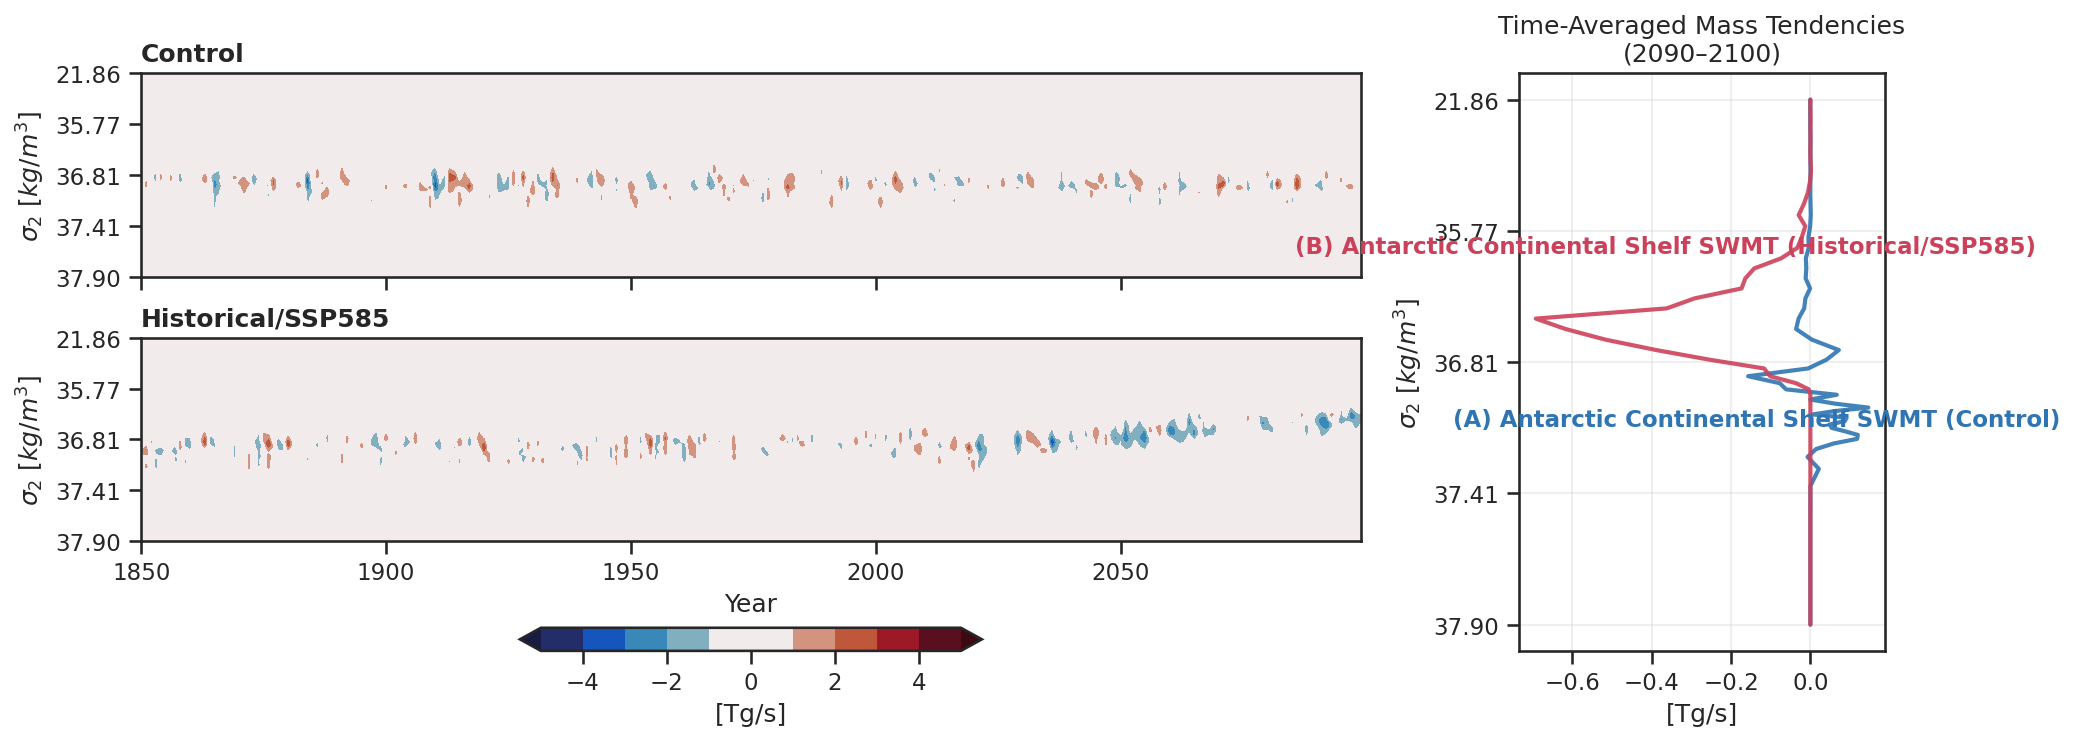

In [5]:
# Create a 2×2 GridSpec where the right column spans both rows
from matplotlib.colors import TwoSlopeNorm

fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.3], wspace=0.2, hspace=0.3)

# Left column: two stacked contour plots
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)

# Right column: one plot spanning both rows
ax_side = fig.add_subplot(gs[:, 1])

ax = [ax0, ax1, ax_side]
year = psi40_abyssal.year
density =  psi40_abyssal.sigma2_l_target
telescope_power = 10
transformed_density = density_transform(density, telescope_power)

TIME, DENS = np.meshgrid(year, transformed_density)

levels = np.arange(-5, 5 + 0.1, 1.)
vmin = np.min(levels); vmax = np.max(levels)
cmap = extend_center_color(cmo.balance, vmin, vmax, center_min=-1, center_max=1)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)


ax[0].contourf(TIME,DENS, 
               toTg * abyssal_dmdt.sel(exp = "control").T, 
               levels = levels, extend = "both", cmap = cmap, norm = norm)

cm = ax[1].contourf(TIME,DENS, 
               toTg * abyssal_dmdt.sel(exp = "forced").T, 
               levels = levels, extend = "both", cmap = cmap, norm = norm)

fig.colorbar(cm, ax = ax[0:2], orientation = "horizontal", fraction = 0.04, label = "[Tg/s]")

ax[0].set_title("Control", loc='left', fontweight = "bold")
ax[1].set_title("Historical/SSP585", loc='left', fontweight = "bold")
ax[0].tick_params(labelbottom=False)
ax[1].set_xlabel("Year")

formatter = create_density_formatter(density, transformed_density)

for a in ax: 
    a.tick_params(bottom=True, left=True)
    a.set_ylabel(r"$\sigma_2$" + " " + r"$[kg/m^3]$")
    a.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    a.invert_yaxis()


abyssal_stats = toTg* abyssal_dmdt.astype(np.float64).sel(year = slice(2050, 2100)).quantile([0.05, 0.5, 0.95], dim="year")

control_stats = abyssal_stats.sel(exp = "control");
forced_stats = abyssal_stats.sel(exp = "forced"); 

ax[-1].plot(control_stats.sel(quantile = 0.5), transformed_density, c = expt_colors["control"], alpha = .9, lw = 2)
ax[-1].plot(forced_stats.sel(quantile = 0.5), transformed_density, c = expt_colors["forced"], alpha = .9, lw = 2)

# Use axis coordinates (0 to 1 range)
ax[-1].text(0.65, 0.4, '(A) Antarctic Continental Shelf SWMT (Control)', 
            color=expt_colors["control"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

ax[-1].text(0.4, 0.7, "(B) Antarctic Continental Shelf SWMT (Historical/SSP585)",
            color=expt_colors["forced"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

# fig.suptitle("Antarctic Continental Shelf Mass Tendencies " + r"", x = 0.37)

ax[-1].set_title("Time-Averaged Mass Tendencies\n(2090–2100)")
ax[-1].set_xlabel("[Tg/s]")
ax[-1].grid(alpha = 0.3)

xticks = ax1.get_yticks()
ax_side.set_yticks(xticks);

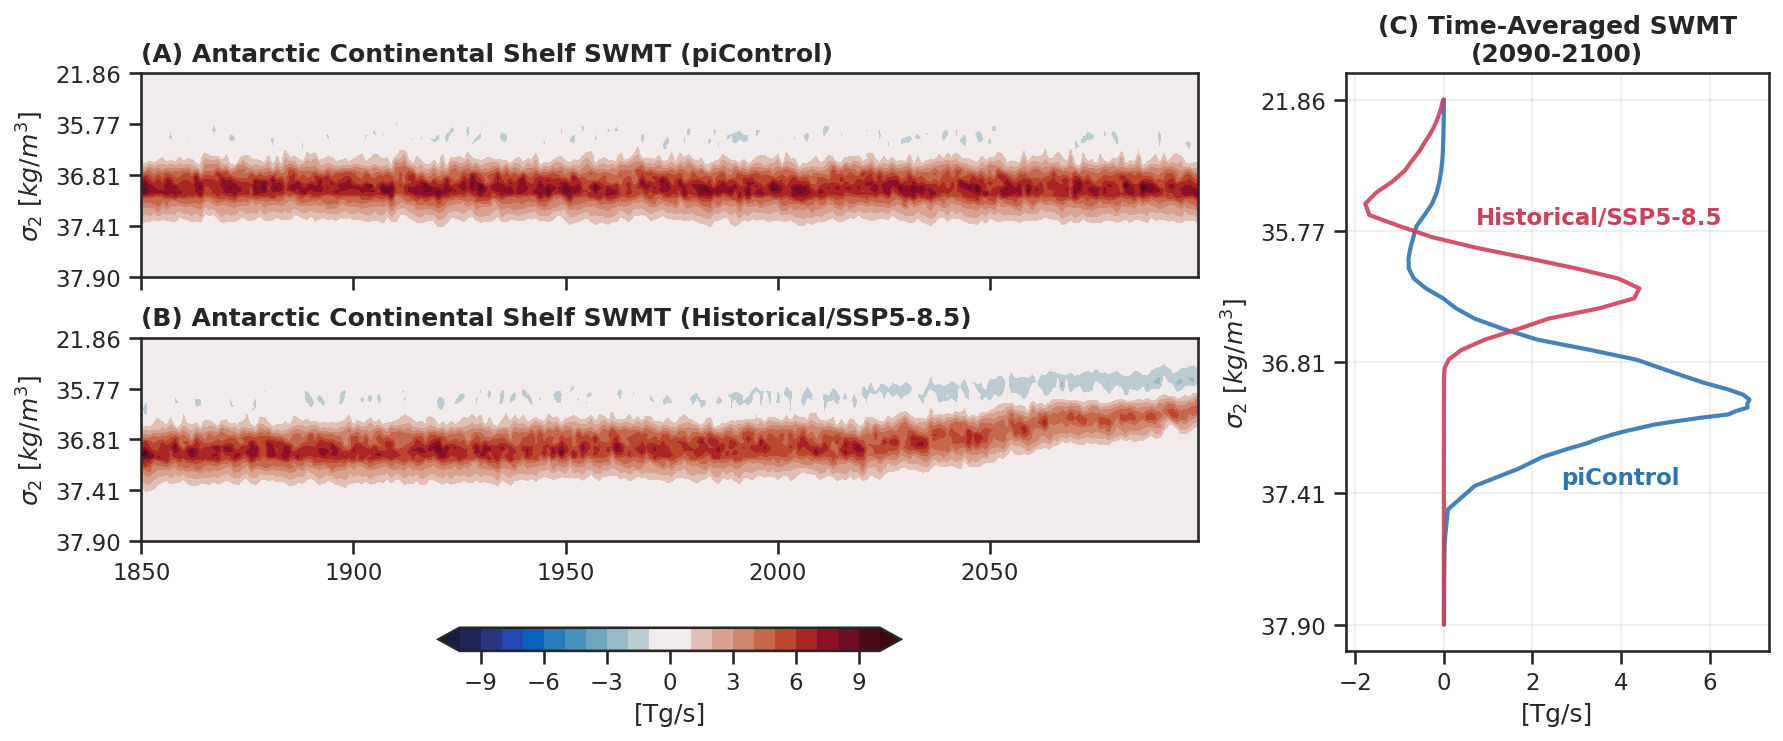

In [102]:
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.4], wspace=0.2, hspace=0.3)

# Left column: two stacked contour plots
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)

# Right column: one plot spanning both rows
ax_side = fig.add_subplot(gs[:, 1])

ax = [ax0, ax1, ax_side]
ax[0].tick_params(labelbottom=False)

year = abyssal_sbf.year
density =  abyssal_sbf.sigma2_l_target
telescope_power = 10
transformed_density = density_transform(density, telescope_power)

TIME, DENS = np.meshgrid(year, transformed_density)

levels = np.arange(-10, 10 + 0.01, 1.0)
vmin = np.min(levels); vmax = np.max(levels)
cmap = extend_center_color(cmo.balance, vmin, vmax, center_min=-1, center_max=1)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# norm = BoundaryNorm(levels, cmo.balance.N)

cm = ax[0].contourf(TIME,DENS, 
               toTg * abyssal_sbf.sel(exp = "control").T, 
               levels = levels, extend = "both", cmap = cmap, norm = norm)

ax[1].contourf(TIME,DENS, 
               toTg * abyssal_sbf.sel(exp = "forced").T, 
               levels = levels, extend = "both", cmap = cmap)

fig.colorbar(cm, ax = ax[0:2], orientation = "horizontal", fraction = 0.04, label = "[Tg/s]")

# fig.suptitle("", x = 0.37)
ax[0].set_title("(A) Antarctic Continental Shelf SWMT (piControl)", loc='left', fontweight = "bold")
ax[1].set_title("(B) Antarctic Continental Shelf SWMT (Historical/SSP5-8.5)", loc='left', fontweight = "bold")

formatter = create_density_formatter(density, transformed_density)

for a in ax: 
    a.tick_params(bottom=True, left=True)
    a.set_ylabel(r"$\sigma_2$" + " " + r"$[kg/m^3]$")
    a.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    a.invert_yaxis()

abyssal_sbf_mean = abyssal_sbf.sel(year = slice(2090, 2100)).mean("year")
abyssal_sbf_mean = toTg *abyssal_sbf_mean
control_mean = abyssal_sbf_mean.sel(exp = "control"); #control_mean = control_mean.where(np.abs(control_mean) > 1e-8)
forced_mean = abyssal_sbf_mean.sel(exp = "forced"); #forced_mean = forced_mean.where(np.abs(forced_mean) > 1e-8)

ax[-1].plot(control_mean, transformed_density, c = expt_colors["control"], label = "control", alpha = .9, lw = 2)
ax[-1].plot(forced_mean, transformed_density, c = expt_colors["forced"], label = "forced", alpha = .9, lw = 2)
# Use axis coordinates (0 to 1 range)
ax[-1].text(0.65, 0.3, 'piControl', 
            color=expt_colors["control"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

ax[-1].text(0.6, 0.75, "Historical/SSP5-8.5",
            color=expt_colors["forced"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

ax[-1].set_title("(C) Time-Averaged SWMT\n(2090-2100)", fontweight = "bold")
ax[-1].set_xlabel("[Tg/s]")
ax[-1].grid(alpha = 0.3)

xticks = ax1.get_yticks()
ax_side.set_yticks(xticks);
fig.savefig("plots/ASC_SWMT.png", dpi = 250, bbox_inches = "tight")

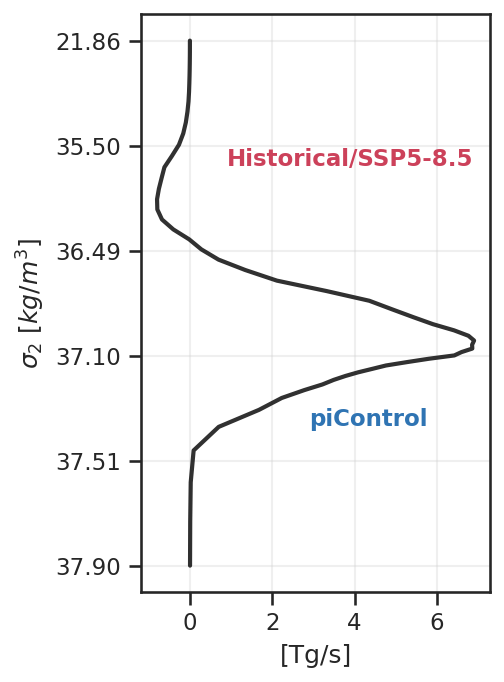

In [136]:
fig, ax = plt.subplots(figsize=(3, 5))

year = abyssal_sbf.year
density =  abyssal_sbf.sigma2_l_target
telescope_power = 10
transformed_density = density_transform(density, telescope_power)

abyssal_sbf_mean = abyssal_sbf.sel(year = slice(2090, 2100)).mean("year")
abyssal_sbf_mean = toTg *abyssal_sbf_mean
control_mean = abyssal_sbf_mean.sel(exp = "control"); #control_mean = control_mean.where(np.abs(control_mean) > 1e-8)
forced_mean = abyssal_sbf_mean.sel(exp = "forced"); #forced_mean = forced_mean.where(np.abs(forced_mean) > 1e-8)

ax.plot(control_mean, transformed_density, c = "k", label = "control", alpha = .9, lw = 2)
# Use axis coordinates (0 to 1 range)
ax.text(0.65, 0.3, 'piControl', 
            color=expt_colors["control"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax.transAxes)

ax.text(0.6, 0.75, "Historical/SSP5-8.5",
            color=expt_colors["forced"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax.transAxes)

ax.set_xlabel("[Tg/s]")
ax.grid(alpha = 0.3)

ax.tick_params(bottom=True, left=True)
ax.set_ylabel(r"$\sigma_2$" + " " + r"$[kg/m^3]$")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
ax.invert_yaxis()
fig.savefig("plots/SWMT_example.png", dpi = 250, bbox_inches = "tight")

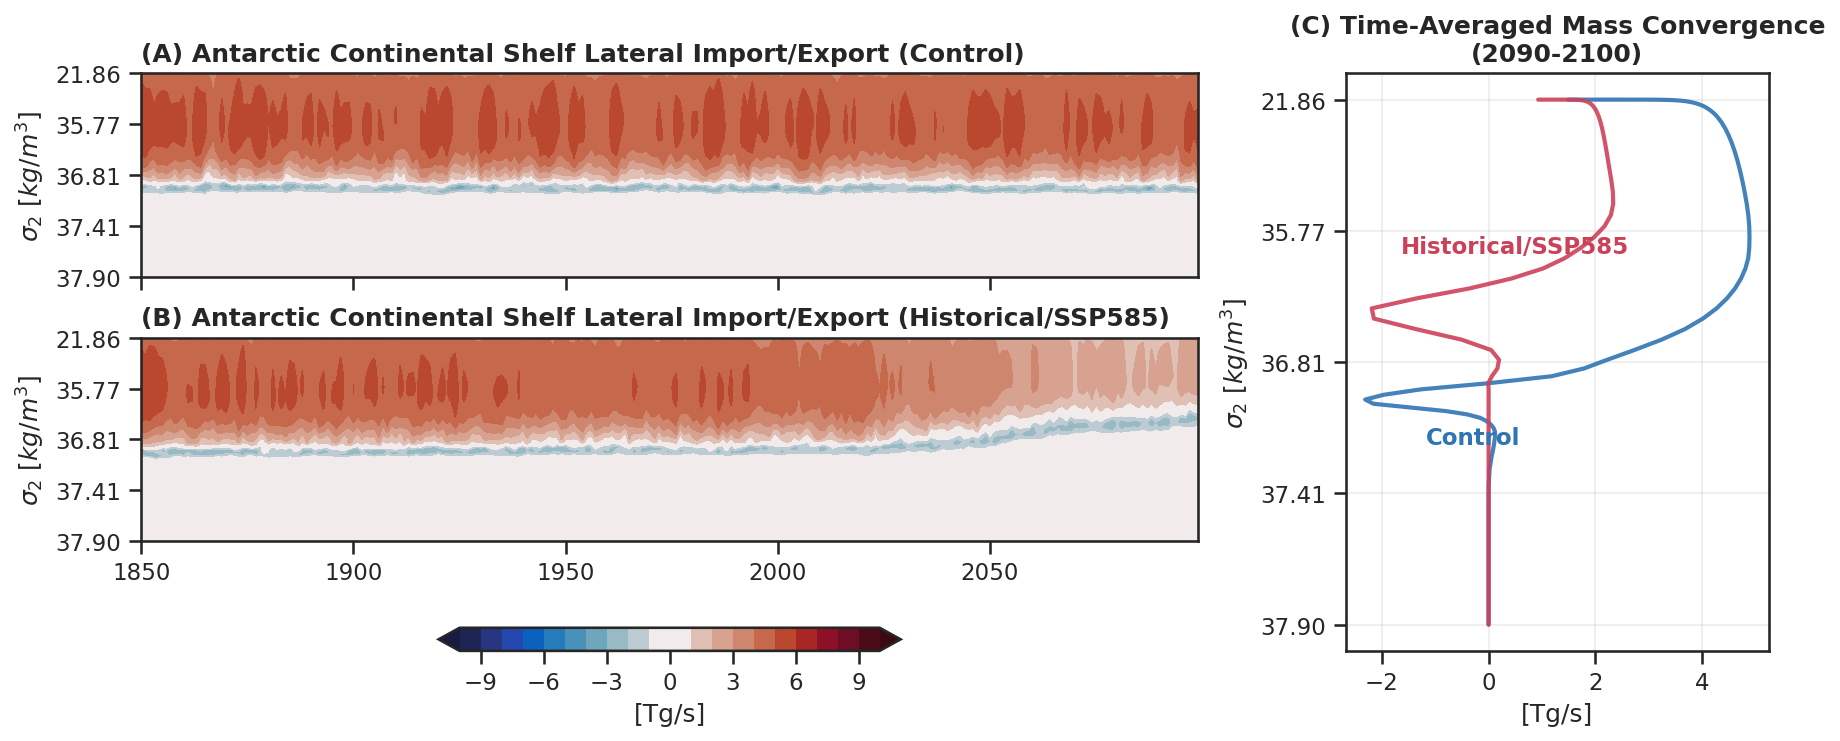

In [7]:
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.4], wspace=0.2, hspace=0.3)

# Left column: two stacked contour plots
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)

# Right column: one plot spanning both rows
ax_side = fig.add_subplot(gs[:, 1])

ax = [ax0, ax1, ax_side]
ax[0].tick_params(labelbottom=False)

year = psi40_abyssal.year
density =  psi40_abyssal.sigma2_l_target
telescope_power = 10
transformed_density = density_transform(density, telescope_power)

TIME, DENS = np.meshgrid(year, transformed_density)

levels = np.arange(-10, 10 + 0.1, 1.0)
vmin = np.min(levels); vmax = np.max(levels)
cmap = extend_center_color(cmo.balance, vmin, vmax, center_min=-1, center_max=1)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

ax[0].contourf(TIME,DENS, 
               toTg * psi40_abyssal.sel(exp = "control").T, 
               levels = levels, extend = "both", cmap = cmap)

cm = ax[1].contourf(TIME,DENS, 
               toTg * psi40_abyssal.sel(exp = "forced").T, 
               levels = levels, extend = "both", cmap = cmap)

fig.colorbar(cm, ax = ax[0:2], orientation = "horizontal", fraction = 0.04, label = "[Tg/s]")

# fig.suptitle("", x = 0.4)
ax[0].set_title("(A) Antarctic Continental Shelf Lateral Import/Export (Control)", loc='left', fontweight = "bold")
ax[1].set_title("(B) Antarctic Continental Shelf Lateral Import/Export (Historical/SSP585)", loc='left', fontweight = "bold")

formatter = create_density_formatter(density, transformed_density)

for a in ax: 
    a.tick_params(bottom=True, left=True)
    a.set_ylabel(r"$\sigma_2$" + " " + r"$[kg/m^3]$")
    a.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    a.invert_yaxis()

psi40_abyssal_mean = psi40_abyssal.sel(year = slice(2090, 2100)).mean("year")
psi40_abyssal_mean = toTg *psi40_abyssal_mean
control_mean = psi40_abyssal_mean.sel(exp = "control"); #control_mean = control_mean.where(np.abs(control_mean) > 1e-8)
forced_mean = psi40_abyssal_mean.sel(exp = "forced"); #forced_mean = forced_mean.where(np.abs(forced_mean) > 1e-8)

ax[-1].plot(control_mean, transformed_density, c = expt_colors["control"], label = "control", alpha = .9, lw = 2)
ax[-1].plot(forced_mean, transformed_density, c = expt_colors["forced"], label = "forced", alpha = .9, lw = 2)
ax[-1].text(0.3, 0.37, 'Control', 
            color=expt_colors["control"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

ax[-1].text(0.4, 0.7, "Historical/SSP585",
            color=expt_colors["forced"], 
            fontsize=11, fontweight='bold', va='center', ha='center',
            transform=ax[-1].transAxes)

ax[-1].set_title("(C) Time-Averaged Mass Convergence\n(2090-2100)", fontweight = "bold")
ax[-1].set_xlabel("[Tg/s]")
ax[-1].grid(alpha = 0.3)

xticks = ax1.get_yticks()
ax_side.set_yticks(xticks);
fig.savefig("plots/ASC_Psi.png", dpi = 250, bbox_inches = "tight")

## Calculating Maximum Overturning

In [13]:
from spatial_decompostion import *

reference_period = '1900-2000'
pert_period = '2090-2100'
times2tuple= lambda s: tuple(map(int,s))

times = [("1900", "2000"), ("2090", "2100")]

reference_focus_time = times2tuple(times[0])
proj_focus_time = times2tuple(times[1])

ds_maximum_sbf_and_psi = xr.open_dataset(datadir("/model/Southern_Ocean_DSW_1000m_max_SWMT.zarr"))

mean_swmt_ds = xr.open_dataset(datadir("/model/DSW_SWMT_periods.zarr"))
mean_swmt = {
    str(k): mean_swmt_ds.sel(period=k).drop_vars("period")
    for k in mean_swmt_ds.coords["period"].values.tolist()
}

ds_diff_decomp = get_variable_spatial_decompose(mean_swmt, var = "SWMT") 
ds_ref_sum = toTg * get_variable_spatial_sum_reference(mean_swmt, var = "SWMT") 
ds_pert_sum =  toTg * get_variable_spatial_sum_pert(mean_swmt, var = "SWMT") 


## Making a budget for a lagrangrian density class

In [35]:
max_sbf_loc = ds_maximum_sbf_and_psi["max_surface_boundary_flux_density"]
sigma_mean = max_sbf_loc.sel(exp = "control").mean("year")
sigma_nearest_control = ds.sigma2_l_target.sel(sigma2_l_target = sigma_mean, method = "nearest")

In [41]:
toTg = 1e-9 
mass_flux_units = "Tg/s"
mass_flux_units_conversion = toTg #kg to Tg 
sigma = np.round(sigma_nearest.values, decimals = 3)
# sigma = 36.974
# tendencies = mass_flux_units_conversion * ds.sel(sigma2_l_target = sigma, method = "nearest").compute()

tendencies = mass_flux_units_conversion * select_from_location(ds_yearly, max_sbf_loc)
tendencies_fixed = mass_flux_units_conversion * ds_yearly.sel(sigma2_l_target = sigma_nearest_control.values, method = "nearest")

# tendencies = tendencies.groupby("time.year").mean("time")
tendencies = tendencies.sel(year = slice("1850", None))
tendencies_fixed = tendencies_fixed.sel(year = slice("1850", None))

In [42]:
budgets = ['mass_tendency', 
           'surface_boundary_fluxes',
           # 'surface_ocean_flux_advective_negative_rhs_salt',
           'diffusion', 
           'spurious_numerical_mixing',
           'convergent_mass_transport', 
           # "bottom_flux_heat", #this term is basically zero 
           ]

budgets_labels = ["Mass\nTendency", 
                  # r"$\mathcal{G}^{SFC, \theta}_\geq$",
                  # r"$\mathcal{G}^{SFC, FW}_\geq$",
                  "SWMT",
                  "Diffusion",
                  "Numerical\nMixing",
                  "Lateral Import/\nExport", 
                  # r"$\mathcal{G}^{\theta_{BOT}}_\geq$", 
                  ]



In [124]:
SWMT_var_to_label = {
    # heat budget
    "SWMT":             "net surface transformation",

    "SWMT_heat":             "heat",
    "SWMT_heat_latent":      "Latent\nheat flux",
    "SWMT_heat_frazil":      "Frazil ice\nheat flux",
    "SWMT_heat_longwave":    "Longwave\nheat flux",
    "SWMT_heat_shortwave":   "Shortwave\nheat flux",
    "SWMT_heat_mass_transfer":"Mass transfer",
    "SWMT_heat_sensible":    "Sensible\nheat flux",
    "SWMT_salt_residual":    "salt residual",
    "SWMT_residual":    "residual",

    # # salt budget
    "SWMT_salt":             "salt",
    "SWMT_salt_evaporation": "Evaporation",
    "SWMT_salt_precipitation":"Precipitation",
    "SWMT_salt_rivers":      "River\nfreshwater flux",
    "SWMT_salt_icebergs":    "Iceberg\nfreshwater flux",
    "SWMT_salt_basal_salt":  "Basal salt flux",
    "SWMT_salt_sea_ice":     "Sea-ice\nfreshwater flux",
    "SWMT_heat_residual":    "heat residual",
    "SWMT_salt_precip_minus_evaporation": "Precipitation/\nEvaporation",
    "other_terms": "other terms"

}

In [45]:
tendencies_SWMT =  get_SWMT(tendencies)
tendencies_SWMT_fixed = get_SWMT(tendencies_fixed)
exclude_vars = {"boundary_fluxes_heat", "SWMT", "SWMT_salt_approx", "SWMT_heat_approx", "SWMT_heat", "SWMT_salt"}
SWMT_decomp_vars = set(tendencies_SWMT.data_vars) - exclude_vars

tendencies_SWMT_subset = tendencies_SWMT[["SWMT", "SWMT_salt_sea_ice", "SWMT_heat_sensible", "SWMT_heat_shortwave", "SWMT_heat_latent"]]
main_terms = ["SWMT_salt_sea_ice", "SWMT_heat_sensible", "SWMT_heat_shortwave", "SWMT_heat_latent"]
tendencies_SWMT_subset["other_terms"] = 1.0 * tendencies_SWMT_subset["SWMT"]
for k in main_terms:
    tendencies_SWMT_subset["other_terms"] -= tendencies_SWMT_subset[k]

main_terms += ["other_terms"]

main_terms_labels = [SWMT_var_to_label[k].replace(' ',"\n") for k in main_terms]

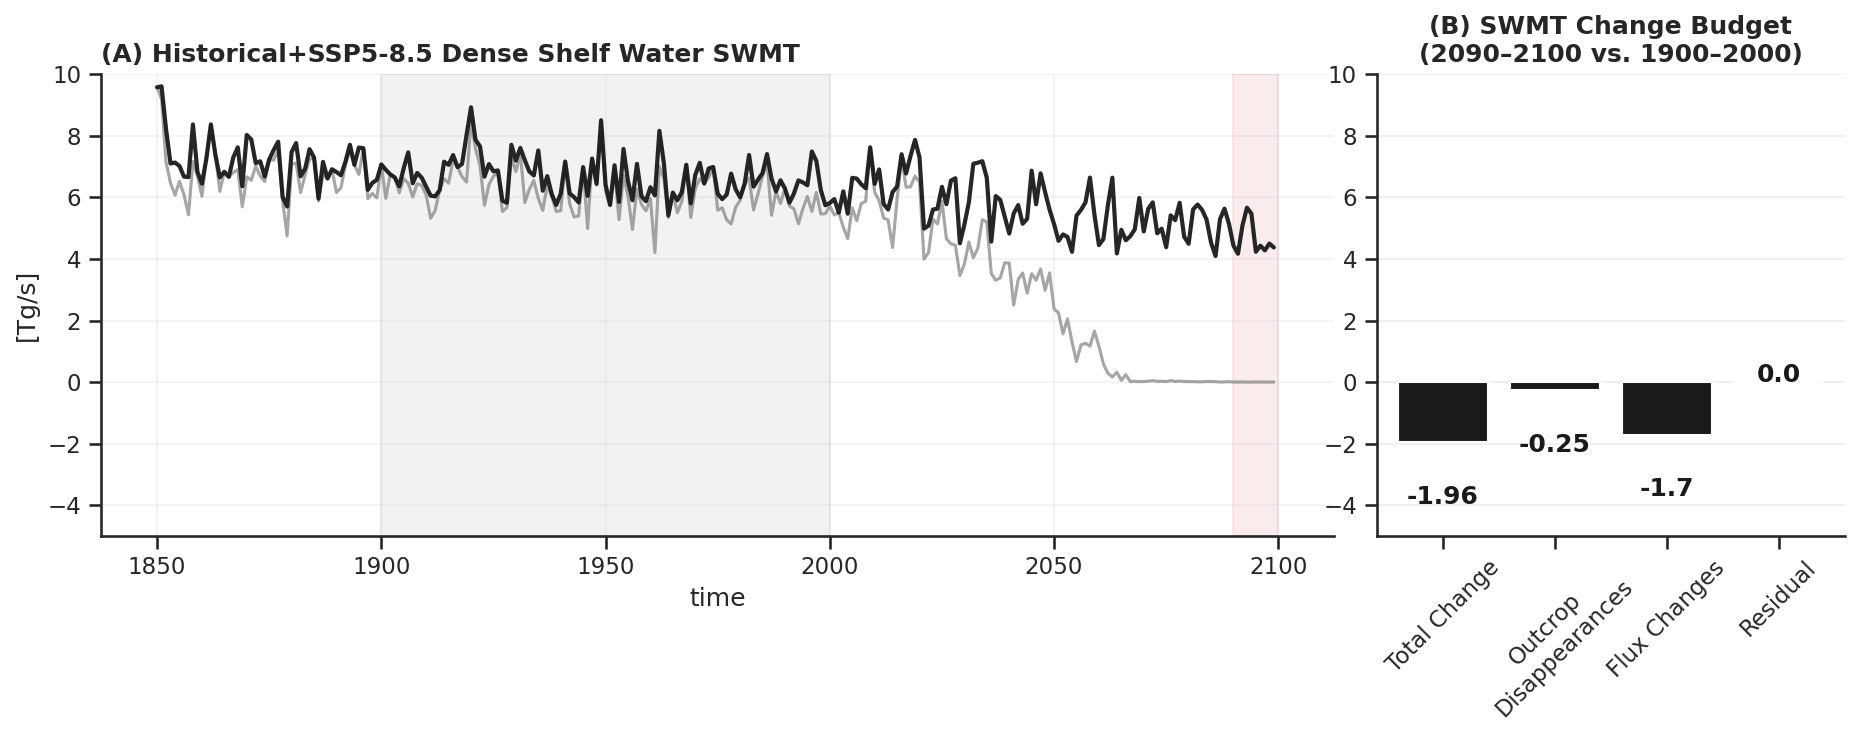

In [101]:
# Create a figure
fig = plt.figure(figsize=(15, 4))

# Create a GridSpec with 4 columns, where the first plot takes up 3/4 and the second takes 1/4
gs = gridspec.GridSpec(1, 7)

###### PLOT 1. TIME SERIES ###########
ax1 = fig.add_subplot(gs[0, :5])
ax = ax1
ax.grid(alpha = 0.4, axis = "y")
width = 0.3

ax.grid(alpha = 0.2)

# ax.plot(tendencies.year, tendencies["mass_tendency"].sel(exp = "control"), 
#         label = "CM4Xp125\nforced", linewidth = 1.5, alpha = 0.95, c = expt_colors["control"])
ax.plot(tendencies_SWMT_fixed.year, tendencies_SWMT_fixed["SWMT"].sel(exp = "forced"), 
        label = "CM4Xp125\nforced", linewidth = 1.5, alpha = 0.7, c = "grey")

ax.plot(tendencies_SWMT.year, tendencies_SWMT["SWMT"].sel(exp = "forced"), 
        label = "CM4Xp125\nforced", linewidth = 2.0, alpha = 0.95, c = "k")

ax.set_ylabel(f"[{mass_flux_units}]")

ax.set_title("(A) Historical+SSP5-8.5 Dense Shelf Water SWMT", fontweight = "bold", loc='left')
ax.set_xlabel("time")
ax.tick_params(bottom=True, left=True)

ax.axvspan(reference_focus_time[0], reference_focus_time[1], color='grey' , alpha=0.1, zorder = 0)
ax.axvspan(proj_focus_time[0], proj_focus_time[1], color=expt_colors["forced"], alpha=0.1, zorder = 0)

###### PLOT 2. BAR PLOT ###########

outcrop_shift = toTg * ds_diff_decomp["domain_shift"]
flux_change_on_preexist_outcrop = toTg * ds_diff_decomp["integrand_change"]
true_diff = toTg * ds_diff_decomp["true_total"]
residual = true_diff - (toTg *  ds_diff_decomp["reconstructed_total"])
other_terms = (true_diff - residual) - (outcrop_shift + flux_change_on_preexist_outcrop)
residual = np.round(residual, 2) + 0.0
other_terms = np.round(other_terms, 2) + 0.0

lab_to_data = {
    "Total Change": true_diff,
    "Outcrop\nDisappearances": outcrop_shift,
    "Flux Changes":  flux_change_on_preexist_outcrop,
    "Residual":  other_terms + residual}


ax2 = fig.add_subplot(gs[0, 5:], sharey = ax1)
ax = ax2
ax.set_title("(B) SWMT Change Budget\n(2090–2100 vs. 1900–2000)", fontweight = "bold", loc='center')
labs = [k for k in lab_to_data.keys()]
bars= ax.bar(labs, [lab_to_data[k].values for k in labs], color = "k") #change to grey red 
# add_bar_numbers(bars, ax)
for t in ax.get_xticklabels():
    t.set_rotation(45)
    t.set_ha("center")
ax.grid(alpha = 0.3)
ax.xaxis.grid(False)
add_bar_numbers(bars, ax)


for a in [ax1, ax2]:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.set_ylim(-5, 10)

fig.savefig("plots/DSW_SWMT_Budget.png", dpi = 250, bbox_inches = "tight")

In [ ]:
exclude_vars = {"boundary_fluxes_heat", "SWMT", "SWMT_salt_approx", "SWMT_heat_approx", "SWMT_heat", "SWMT_salt", "SWMT_heat_residual", "SWMT_salt_residual", "SWMT_residual"}
decomp_vars = sorted(list(set(tendencies_SWMT.data_vars) - exclude_vars))

# decomp_vars = ["SWMT_salt_sea_ice", "SWMT_heat_sensible", "SWMT_heat_shortwave"]
decomp_labels = [SWMT_var_to_label[var] + "\ncontribution" for var in decomp_vars]
decomp_integrand_change = [toTg * get_variable_integrand_change(mean_swmt, var = var).values for var in decomp_vars]

decomp_vars = np.array(decomp_vars)[np.argsort(np.abs(np.array(decomp_integrand_change)))[::-1].tolist()]
decomp_labels = [SWMT_var_to_label[var] + "\ncontribution" for var in decomp_vars]
decomp_integrand_change = [toTg * get_variable_integrand_change(mean_swmt, var = var).values for var in decomp_vars]

decomp_integrand_change = [flux_change_on_preexist_outcrop.values] + decomp_integrand_change
decomp_labels = ["SWMT Change\ndue to\nflux change"] + decomp_labels

sorted_decomp_idx = np.argsort(np.abs(decomp_integrand_change))[::-1]
decomp_integrand_change = np.array(decomp_integrand_change)[sorted_decomp_idx]
decomp_labels = np.array(decomp_labels)[sorted_decomp_idx]

colors= ["k"] + sns.color_palette("colorblind", len(decomp_integrand_change)-1)

fig, ax = plt.subplots(figsize = (12, 5))
bars = ax.bar(decomp_labels, decomp_integrand_change, align='center', color = colors)
ax.tick_params(axis='x', labelrotation=45, labelright=False)

ax.set_ylim(-2.7, 1.5)
ax.set_ylabel("[Tg/s]")
ax.grid(alpha = 0.3)
ax.xaxis.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", labelsize=9)  # change fontsize of xticklabels

add_bar_numbers(bars, ax, text_height_factor = 0.5)
fig.savefig("plots/DSW_SWMT_FluxChange_Full_Budget.png", dpi = 250, bbox_inches = "tight")